In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint 
from IPython.display import Image, display 

In [6]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [7]:
load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3-70B-Instruct",
    task="text-generation",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

e:\CV\InfoDevelopers\Internship\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
def gen_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f"Generate the detailed outline for blog on the title {title}"
    
    outine = model.invoke(prompt).content
    
    state['outline'] = outine
    
    return state

In [10]:
def gen_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    prompt = f"Write a detailed blog on the title - {title} with the following detail - {outline}"
    
    content = model.invoke(prompt).content
    
    state['content'] = content
    
    return state

In [12]:
graph = StateGraph(BlogState)
graph.add_node("gen_outline", gen_outline)
graph.add_node("gen_blog", gen_blog)

graph.add_edge(START, "gen_outline")
graph.add_edge("gen_outline", "gen_blog")
graph.add_edge("gen_blog", END)

workflow = graph.compile()




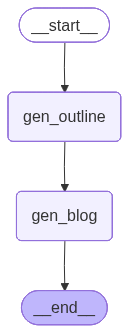

In [15]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [16]:
inital_state = {'title': 'Tourism in Nepal'}
final_state = workflow.invoke(inital_state)

print(final_state)

{'title': 'Tourism in Nepal', 'outline': 'Here is a detailed outline for a blog on "Tourism in Nepal":\n\n**I. Introduction**\n\n* Brief overview of Nepal\'s tourism industry\n* Importance of tourism in Nepal\'s economy\n* Thesis statement: Nepal is a treasure trove of natural beauty, cultural heritage, and adventure opportunities, making it an ideal destination for tourists.\n\n**II. Natural Beauty of Nepal**\n\n* Description of Nepal\'s geographical diversity (Himalayas, hills, plains)\n* Famous natural attractions:\n\t+ Mount Everest and other Himalayan peaks\n\t+ Lakes (e.g. Phewa Lake, Rara Lake)\n\t+ National parks and wildlife reserves (e.g. Chitwan National Park, Langtang National Park)\n\t+ Waterfalls and hot springs\n* Importance of eco-tourism in Nepal\n\n**III. Cultural Heritage of Nepal**\n\n* Overview of Nepal\'s rich cultural heritage\n* Famous cultural attractions:\n\t+ UNESCO World Heritage Sites (e.g. Kathmandu Durbar Square, Bhaktapur Durbar Square)\n\t+ Temples and 